# 1. Imports et préparation

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupKFold

sys.path.append(str(Path("..").resolve()))

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


def compute_cmapss_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
  """Score asymétrique officiel NASA C-MAPSS."""
  d = np.array(y_pred) - np.array(y_true)
  score = np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)
  return float(np.sum(score))


def evaluate_predictions(
    y_true: np.ndarray, y_pred: np.ndarray, model_name: str = "Modèle"
) -> dict:
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  mae = mean_absolute_error(y_true, y_pred)
  score = compute_cmapss_score(y_true, y_pred)
  print(f"=== {model_name} ===")
  print(f"RMSE       : {rmse:.2f} cycles")
  print(f"MAE        : {mae:.2f} cycles")
  print(f"Score NASA : {score:.2f}\n")
  return {"model": model_name, "RMSE": rmse, "MAE": mae, "NASA_Score": score}

# 2. Chargement des données prétraitées

Le jeu de test C-MAPSS ne fonctionne pas comme le jeu d'entraînement.
La différence fondamentale entre Train et Test découle du fait que:
  - Dans le jeu d'entraînement (df_train) :

Chaque moteur a tourné jusqu'à la casse complète (RUL = 0). On connaît la trajectoire de bout en bout, cycle par cycle.

  - Dans le jeu de test (df_test) :

Les séries temporelles ont été coupées volontairement avant la panne par la NASA.

Le problème  est donc :

« Voici les enregistrements d'un moteur jusqu'à son dernier vol connu. Devine combien de cycles il lui reste à vivre à partir de ce dernier point précis. »

In [3]:
DATA_PROCESSED = Path("../data/processed")
DATA_RAW = Path("../data/raw")

df_train = pd.read_parquet(DATA_PROCESSED / "train_FD004_features.parquet")
df_test = pd.read_parquet(DATA_PROCESSED / "test_FD004_features.parquet")

# Cible réelle pour les 248 moteurs de test
rul_true = pd.read_csv(
    DATA_RAW / "RUL_FD004.txt", sep=r"\s+", header=None, names=["rul"]
) # Dans ce dataset, La première ligne donne la RUL restante du moteur 1 à son dernier cycle enregistré, la deuxième ligne celle du moteur 2, etc
y_test = rul_true["rul"].clip(upper=125).values # on applique le même plafond à 125 cycles que sur le train pour évaluer le modèle dans les mêmes conditions

# Sélection des variables (exclusion des métadonnées)
""""On retire les colonnes qu'un modèle ne doit pas utiliser :
 - unit_id : le numéro du moteur (ce n'est pas une mesure physique, le modèle ne doit pas mémoriser des numéros de série)
 - time_cycles : le cycle actuel (dans le test, un moteur peut avoir moins de cycles parce qu'il a été arrêté tôt, cela fausserait l'apprentissage)
 - rul et rul_clipped : ce sont les réponses à prédire (les cibles ), les laisser dans X serait de la triche (data leakage)
 - op_regime : l'identifiant du cluster de vol (on préfère les capteurs déjà normalisés et les rolling features)

 """

exclude_cols = ["unit_id", "time_cycles", "rul", "rul_clipped", "op_regime"]
feature_cols = [c for c in df_train.columns if c not in exclude_cols]

X_train = df_train[feature_cols]
y_train = df_train["rul_clipped"]
groups = df_train[
    "unit_id"
]  # Crucial pour la validation par groupe de moteurs

# Pour le test : On regroupe les données par moteur (moteur 1, moteur 2, ..., moteur 248)et on extrait uniquement la dernière mesure connue de chaque moteur
X_test = df_test.groupby("unit_id")[feature_cols].last()

print(f"Variables d'entraînement : {X_train.shape[1]}")
print(f"Lignes train              : {len(X_train)}")
print(f"Moteurs test              : {len(X_test)}")

Variables d'entraînement : 87
Lignes train              : 61249
Moteurs test              : 248


# 3. Entraînement avec GroupKFold


In [4]:
# Initialisation de la validation croisée groupée par moteur
gkf = GroupKFold(n_splits=5) # Les 249 moteurs sont divisés en 5 groupes d'environ 50 moteurs

oof_predictions = np.zeros(len(df_train))
test_preds_folds = np.zeros(len(X_test))
models = []

lgb_params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": 6,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "reg_alpha": 1.0,  # Régularisation L1
    "reg_lambda": 5.0,  # Régularisation L2
    "random_state": 42,
    "verbose": -1,
    "n_jobs": -1,
}

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups)):
  X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
  X_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]

  model = lgb.LGBMRegressor(**lgb_params, n_estimators=600)

  # Entraînement avec early stopping sur le fold de validation
  model.fit(
      X_tr,
      y_tr,
      eval_set=[(X_va, y_va)],
      callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
  )
  """"" - gkf.split fournit les indices des moteurs pour l'entraînement (train_idx) et pour la validation (val_idx)
      - Le modèle va construire jusqu'à 600 arbres. Mais si pendant 30 arbres d'affilée l'erreur de validation sur X_va ne s'améliore plus, il s'arrête automatiquement pour ne pas faire de surapprentissage
      """

  oof_predictions[val_idx] = model.predict(X_va)
  test_preds_folds += model.predict(X_test) / gkf.n_splits # On additionner les prédictions des 5(gkf.n_splits) modèles entraînés pour en faire la moyenne.
  models.append(model)

  fold_rmse = np.sqrt(mean_squared_error(y_va, oof_predictions[val_idx]))
  print(f"Fold {fold + 1} - RMSE de validation : {fold_rmse:.2f} cycles")

cv_rmse = np.sqrt(mean_squared_error(y_train, oof_predictions))
print(f"\n---> RMSE global Out-Of-Fold (CV) : {cv_rmse:.2f} cycles")

c:\Users\aluss\predictive-maintenance-rul\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1 - RMSE de validation : 18.40 cycles


c:\Users\aluss\predictive-maintenance-rul\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2 - RMSE de validation : 15.45 cycles


c:\Users\aluss\predictive-maintenance-rul\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3 - RMSE de validation : 16.82 cycles


c:\Users\aluss\predictive-maintenance-rul\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4 - RMSE de validation : 18.78 cycles


c:\Users\aluss\predictive-maintenance-rul\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 5 - RMSE de validation : 17.36 cycles

---> RMSE global Out-Of-Fold (CV) : 17.41 cycles


# 4. Évaluation sur le jeu de test final

In [5]:
# Post-processing : On applique également un post-traitement en plafonnant les prédictions négatives car la RUL ne peut pas être négative ni excéder le seuil max
y_pred_lgb = np.clip(test_preds_folds, a_min=0, a_max=125)
# Sauvegarder les prédictions finales
np.save(DATA_PROCESSED / "y_pred_lgb.npy", y_pred_lgb)
res_lgb = evaluate_predictions(y_test, y_pred_lgb, model_name="LightGBM")

=== LightGBM ===
RMSE       : 19.10 cycles
MAE        : 13.87 cycles
Score NASA : 3148.03



# 5. Analyse des variables les plus importantes

C:\Users\aluss\AppData\Local\Temp\ipykernel_2592\65130112.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


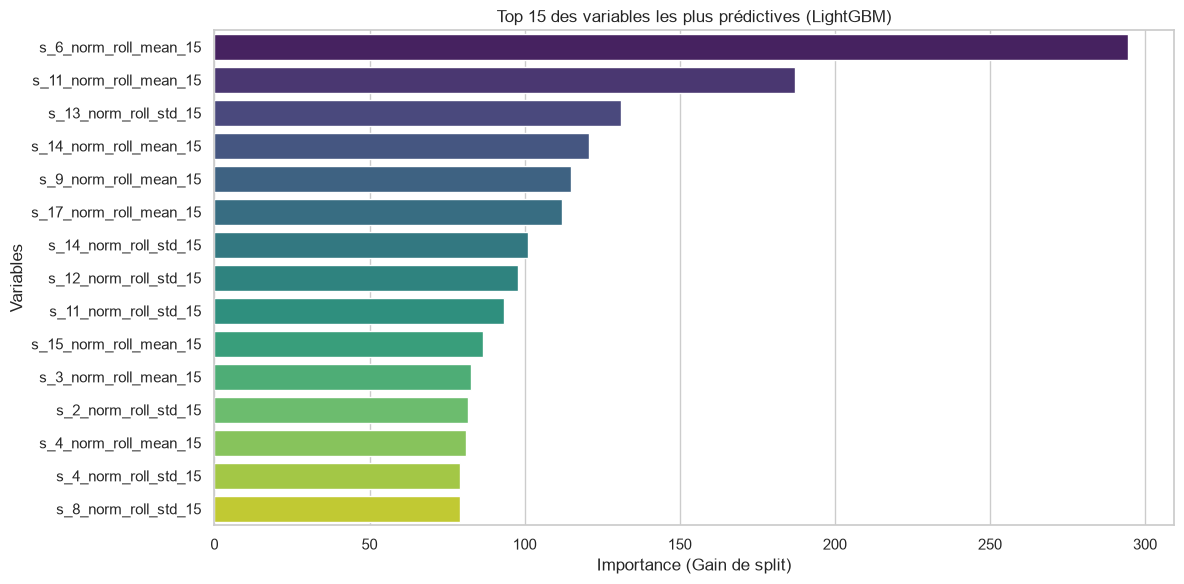

In [6]:
# Moyenne de l'importance des features sur les 5 folds
feature_importances = np.mean(
    [m.feature_importances_ for m in models], axis=0
)
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": feature_importances,
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=importance_df.head(15),
    x="importance",
    y="feature",
    palette="viridis",
)
plt.title("Top 15 des variables les plus prédictives (LightGBM)")
plt.xlabel("Importance (Gain de split)")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# 6.Comparaison visuelle Vraie RUL vs Prédiction

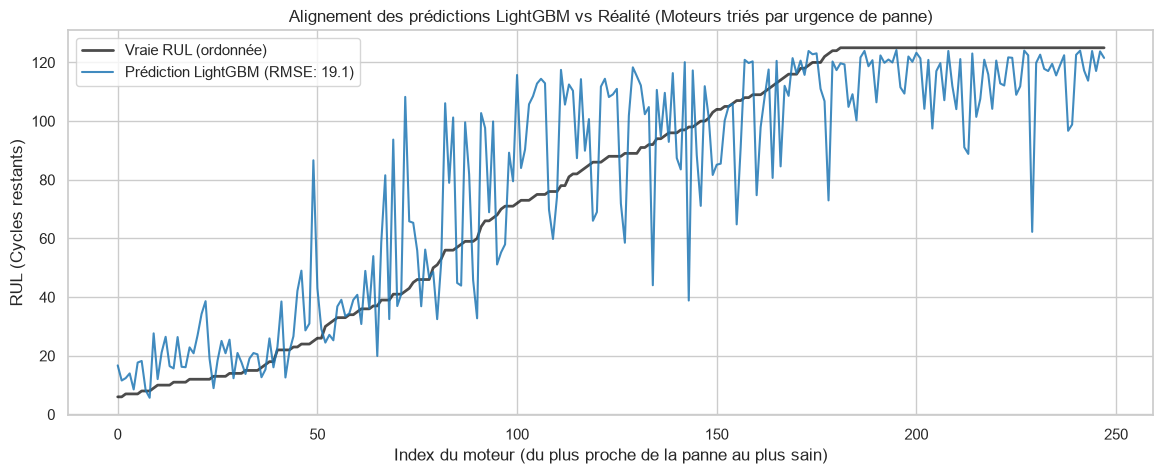

In [ ]:
# Tri des moteurs de test par vraie RUL croissante pour une lecture limpide
sort_idx = np.argsort(y_test)

plt.figure(figsize=(14, 5))
plt.plot(
    y_test[sort_idx],
    label="Vraie RUL (ordonnée)",
    color="black",
    lw=2,
    alpha=0.7,
)
plt.plot(
    y_pred_lgb[sort_idx],
    label=f"Prédiction LightGBM (RMSE: {res_lgb['RMSE']:.1f})",
    color="#1f77b4",
    alpha=0.85,
    lw=1.5,
)
plt.title(
    "Alignement des prédictions LightGBM vs Réalité (Moteurs triés par urgence de panne)"
)
plt.xlabel("Index du moteur (du plus proche de la panne au plus sain)")
plt.ylabel("RUL (Cycles restants)")
plt.legend()
plt.show()